In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from datetime import date
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    FunctionTransformer, StandardScaler,
    OneHotEncoder, OrdinalEncoder, PowerTransformer
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)


---
## 1. Configuration

In [2]:
DATA_PATH    = 'EasyVisa.csv'
TARGET_COL   = 'case_status'
PROBLEM_TYPE = 'classification'

COLS_TO_DROP = ['case_id']

BINARY_YN_COLS = ['has_job_experience', 'requires_job_training', 'full_time_position']

ORDINAL_COLS  = ['education_of_employee']
ORDINAL_ORDER = [["High School", "Bachelor's", "Master's", "Doctorate"]]

ONEHOT_COLS = ['continent', 'region_of_employment']

NUMERIC_COLS = ['prevailing_wage_annual', 'no_of_employees', 'company_age']

# ── Per-column outlier + transformation strategy ─────────────────────────
#
#   Feature                  | Outlier% | Nature              | Strategy
#   ─────────────────────────┼──────────┼─────────────────────┼─────────────────────────────────
#   prevailing_wage_annual   |  9.37%   | Hourly→annual skew  | Winsorize(1%,99%) → Yeo-Johnson
#   no_of_employees          |  6.11%   | Power-law dist.     | Log1p only (log IS the fix)
#   company_age              | 12.79%   | Many recent comps   | Winsorize(5%,95%) → Yeo-Johnson
#

WINSORIZE_PARAMS = {
    'prevailing_wage_annual': (0.01, 0.99),   # moderate clip
    'company_age'           : (0.05, 0.95),   # aggressive clip (high outlier%)
}
LOG1P_COLS       = ['no_of_employees']
YEO_JOHNSON_COLS = ['prevailing_wage_annual', 'company_age']

IMPUTE_MEDIAN = []
IMPUTE_MEAN   = []
IMPUTE_MODE   = []

print('Config loaded.')
print(f'  Numeric cols    : {NUMERIC_COLS}')
print(f'  Winsorize + YeoJ: {YEO_JOHNSON_COLS}')
print(f'  Log1p only      : {LOG1P_COLS}')

Config loaded.
  Numeric cols    : ['prevailing_wage_annual', 'no_of_employees', 'company_age']
  Winsorize + YeoJ: ['prevailing_wage_annual', 'company_age']
  Log1p only      : ['no_of_employees']


---
## 2. Load Data

In [3]:
df=pd.read_csv(DATA_PATH)

In [4]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.20,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.86,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.03,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.39,Year,Y,Certified


In [5]:
df.shape

(25480, 12)

---
## 3. Drop Useless Columns

In [6]:
# Drop columns
if COLS_TO_DROP:
    df.drop(columns=COLS_TO_DROP,inplace=True)
    print("Dropped columns:", COLS_TO_DROP)

# Check constant columns
const_cols = [col for col in df.columns if df[col].nunique() <= 1]

if const_cols:
    print("Constant columns:", const_cols)
else:
    print("No constant columns")


Dropped columns: ['case_id']
No constant columns


In [7]:
print("Shape:", df.shape)

Shape: (25480, 11)


---
## 4. Handle Missing Values

In [8]:
# Median imputation
if IMPUTE_MEDIAN:
    for col in IMPUTE_MEDIAN:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(col, ": filled with median =", round(median_val, 4))

# Mean imputation
if IMPUTE_MEAN:
    for col in IMPUTE_MEAN:
        mean_val = df[col].mean()
        df[col].fillna(mean_val, inplace=True)
        print(col, ": filled with mean =", round(mean_val, 4))

# Mode imputation
if IMPUTE_MODE:
    for col in IMPUTE_MODE:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(col, ": filled with mode =", mode_val)

# Check remaining missing values
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]

if len(remaining) == 0:
    print("\nNo missing values left")
else:
    print("\nMissing values still present:")
    print(remaining)


No missing values left


---
## 5. Data Cleaning

In [9]:
# Check before fix
(df['no_of_employees']<0.).sum()

np.int64(33)

In [10]:
# Fix negative values
df["no_of_employees"] = df["no_of_employees"].abs()

In [11]:
# Check after fix
(df['no_of_employees']<0.).sum()

np.int64(0)

In [12]:
# 4.2 Normalize prevailing_wage to annual salary
# Hour  x 2080 = Annual  (52 weeks x 40 hours)
# Week  x 52   = Annual
# Month x 12   = Annual
# Year  x 1    = Already Annual

wage_multiplier = {
    'Hour': 2080,
    'Week': 52,
    'Month': 12,
    'Year': 1
}

df['prevailing_wage_annual'] = df['prevailing_wage'] * df['unit_of_wage'].map(wage_multiplier)


In [13]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,prevailing_wage_annual
0,Asia,High School,N,N,14513,2007,West,592.20,Hour,Y,Denied,1231782.03
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,Certified,83425.65
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.86,Year,Y,Denied,122996.86
3,Asia,Bachelor's,N,N,98,1897,West,83434.03,Year,Y,Denied,83434.03
4,Africa,Master's,Y,N,1082,2005,South,149907.39,Year,Y,Certified,149907.39


In [14]:
# 4.3 Drop original wage columns — replaced by prevailing_wage_annual
df.drop(columns=['prevailing_wage', 'unit_of_wage'], inplace=True)

In [15]:
df.shape

(25480, 10)

---
## Feature Engineering — Create New Features


In [16]:
# creating the date object of today's date
todays_date = date.today()
current_year= todays_date.year

In [17]:
REFERENCE_YEAR = 2020

**Subtract current year with year of estab to get company's age**

In [18]:
df['company_age'] = REFERENCE_YEAR - df['yr_of_estab']

In [19]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,full_time_position,case_status,prevailing_wage_annual,company_age
0,Asia,High School,N,N,14513,2007,West,Y,Denied,1231782.03,13
1,Asia,Master's,Y,N,2412,2002,Northeast,Y,Certified,83425.65,18
2,Asia,Bachelor's,N,Y,44444,2008,West,Y,Denied,122996.86,12
3,Asia,Bachelor's,N,N,98,1897,West,Y,Denied,83434.03,123
4,Africa,Master's,Y,N,1082,2005,South,Y,Certified,149907.39,15


In [20]:
# 5.2 Drop yr_of_estab — replaced by company_age
df.drop(columns=['yr_of_estab'], inplace=True)

In [21]:
df.describe()

,no_of_employees,prevailing_wage_annual,company_age
count,25480.00,25480.00,25480.00
mean,5667.09,197391.16,40.59
std,22877.92,578591.67,42.37
min,11.00,100.00,4.00
25%,1022.00,47107.96,15.00
50%,2109.00,82839.46,23.00
75%,3504.00,124825.04,44.00
max,602069.00,14569149.40,220.00


In [22]:
df.shape

(25480, 10)

---
## 6. Split X / y — Encode Target

In [23]:
X = df.drop('case_status', axis=1)
y = df['case_status']

In [24]:
X

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,full_time_position,prevailing_wage_annual,company_age
0,Asia,High School,N,N,14513,West,Y,1231782.03,13
1,Asia,Master's,Y,N,2412,Northeast,Y,83425.65,18
2,Asia,Bachelor's,N,Y,44444,West,Y,122996.86,12
3,Asia,Bachelor's,N,N,98,West,Y,83434.03,123
4,Africa,Master's,Y,N,1082,South,Y,149907.39,15
...,...,...,...,...,...,...,...,...,...
25475,Asia,Bachelor's,Y,Y,2601,South,Y,77092.57,12
25476,Asia,High School,Y,N,3274,Northeast,Y,279174.79,14
25477,Asia,Master's,Y,N,1121,South,N,146298.85,110
25478,Asia,Master's,Y,Y,1918,West,Y,86154.77,133


In [25]:
y

0           Denied
1        Certified
2           Denied
3           Denied
4        Certified
           ...    
25475    Certified
25476    Certified
25477    Certified
25478    Certified
25479    Certified
Name: case_status, Length: 25480, dtype: object

**Manual encoding target column**

In [26]:
y=np.where(y=='Denied',1,0)

In [27]:
y

array([1, 0, 1, ..., 0, 0, 0], shape=(25480,))

In [28]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,full_time_position,case_status,prevailing_wage_annual,company_age
0,Asia,High School,N,N,14513,West,Y,Denied,1231782.03,13
1,Asia,Master's,Y,N,2412,Northeast,Y,Certified,83425.65,18
2,Asia,Bachelor's,N,Y,44444,West,Y,Denied,122996.86,12
3,Asia,Bachelor's,N,N,98,West,Y,Denied,83434.03,123
4,Africa,Master's,Y,N,1082,South,Y,Certified,149907.39,15


---
## 7. Exploratory Analysis

In [29]:
numerical_features   = [c for c in X.columns if X[c].dtype != 'O']
categorical_features = [c for c in X.columns if X[c].dtype == 'O']
discrete_features    = [c for c in numerical_features if X[c].nunique() <= 25]
continuous_features  = [c for c in numerical_features if X[c].nunique() >  25]

print('Numerical   :', numerical_features)
print('Categorical :', categorical_features)
print('Continuous  :', continuous_features)
print('Discrete    :', discrete_features)

Numerical   : ['no_of_employees', 'prevailing_wage_annual', 'company_age']
Categorical : ['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'full_time_position']
Continuous  : ['no_of_employees', 'prevailing_wage_annual', 'company_age']
Discrete    : []


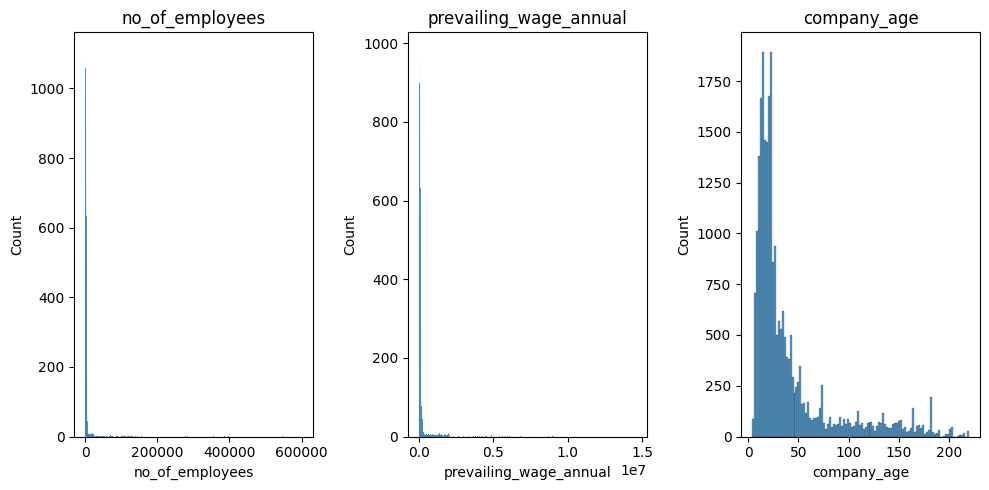

Skewness (full dataset):
no_of_employees          12.27
prevailing_wage_annual    8.98
company_age               2.04
dtype: float64


In [30]:
# Raw distributions — BEFORE any transformation
plt.figure(figsize=(10, 5))

cols = ['no_of_employees', 'prevailing_wage_annual', 'company_age']

for i, col in enumerate(cols):
    plt.subplot(1, 3, i + 1)
    sns.histplot(X[col])
    plt.title(col)

plt.tight_layout()
plt.show()

print('Skewness (full dataset):')
print(X[continuous_features].skew().round(2))

In [31]:
# Check Skewness
X[continuous_features].skew(axis=0, skipna=True)

no_of_employees          12.27
prevailing_wage_annual    8.98
company_age               2.04
dtype: float64

---
## 8. Train-Test Split

> **Critical rule**: All transformations (outlier bounds, transformation parameters, scaler stats)  
> must be **fitted on X_train only** and then applied to X_test.  
> Fitting on the full dataset leaks test information → inflated eval metrics.

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify= y )

In [33]:
print(X_train.shape,X_test.shape)

(20384, 9) (5096, 9)


---
## 9. Outlier Detection — IQR Method (X_train only)

We use IQR only to **understand** the data and confirm our strategy.  
The actual outlier handling happens inside the pipeline (no leakage).

In [34]:
outlier_list = []

for col in continuous_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df[col] < lower) | (df[col] > upper)).sum()
    pct = (count / len(df)) * 100

    if pct < 5:
        action = "Cap"
    else:
        action = "Investigate"

    outlier_list.append([col, round(pct, 2), action])

outlier_df = pd.DataFrame(outlier_list, columns=["Column", "Outlier %", "Action"])
print(outlier_df)

                   Column  Outlier %       Action
0         no_of_employees       6.11  Investigate
1  prevailing_wage_annual       9.37  Investigate
2             company_age      12.79  Investigate


In [35]:
# Skewness from X_train (use this for all transform decisions)
print('Skewness (X_train):')
print(X_train[continuous_features].skew().round(2))

Skewness (X_train):
no_of_employees          12.52
prevailing_wage_annual    9.12
company_age               2.05
dtype: float64


---
## 10. Outlier Handling Strategy — Per Column

We use **different techniques per column** because each feature has a different nature:

| Feature | Outlier % | Nature | Strategy | Reason |
|---|---|---|---|---|
| `prevailing_wage_annual` | 9.37% | Hourly→annual conversion inflates values | **Winsorize 1%–99% → Yeo-Johnson** | Clip extremes, then fix skew |
| `no_of_employees` | 6.11% | Power-law dist. (few giant companies) | **Log1p only** | Log IS the outlier fix for power-law |
| `company_age` | 12.79% | Narrow IQR (most 15–30 yrs), few very old | **Winsorize 5%–95% → Yeo-Johnson** | High %, so more aggressive clip |

### Why Yeo-Johnson instead of plain Log?

| | Log1p | Yeo-Johnson |
|---|---|---|
| Handles negatives? | ❌ No | ✅ Yes |
| Handles zeros? | ✅ (log1p) | ✅ Yes |
| Auto-finds best lambda? | ❌ Fixed | ✅ Yes |
| Use when | Count/ratio features with clear power-law | Everything else — more general |

**Rule of thumb**: Use `log1p` for count-like power-law features (`no_of_employees`).  
Use `Yeo-Johnson` after winsorization for everything else.

### Correct pipeline order (critical):
```
Winsorize  →  clips extremes so Yeo-Johnson sees a clean signal
Yeo-Johnson → fixes skewness → near-normal distribution  
StandardScaler → zero mean, unit variance
```
Scaling before transformation = still skewed after. Wrong order = bad model.

---
## 11. Custom Winsorizer — sklearn-compatible Transformer

`sklearn` has no built-in Winsorizer.  
We write one that **learns quantile bounds from `fit()` on X_train** and  
applies those same bounds in `transform()` — zero leakage.

In [36]:
class Winsorizer(BaseEstimator, TransformerMixin):
    """
    Clips each column to [lower_quantile, upper_quantile] learned from X_train.

    Parameters
    ----------
    lower : float  lower quantile  (e.g. 0.01 = 1st percentile)
    upper : float  upper quantile  (e.g. 0.99 = 99th percentile)
    """
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.n_features_in_ = X.shape[1]          # ← required for fallback names
        self.lower_bounds_  = np.percentile(X, self.lower * 100, axis=0)
        self.upper_bounds_  = np.percentile(X, self.upper * 100, axis=0)
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float).copy()
        return np.clip(X, self.lower_bounds_, self.upper_bounds_)

    def get_feature_names_out(self, input_features=None):
        # 1-to-1 transform: output names = input names
        if input_features is not None:
            return np.asarray(input_features, dtype=object)
        return np.array([f'x{i}' for i in range(self.n_features_in_)], dtype=object)

print('Winsorizer ready.')

Winsorizer ready.


---
## 12. Per-Column Numeric Sub-Pipelines

Three separate pipelines, each tailored to the feature's distribution:

```
prevailing_wage_annual → Winsorize(1%, 99%) → Yeo-Johnson → StandardScaler
no_of_employees        → Log1p              → StandardScaler
company_age            → Winsorize(5%, 95%) → Yeo-Johnson → StandardScaler
```

In [37]:
# prevailing_wage_annual : Winsorize(1%, 99%) → Yeo-Johnson → StandardScaler
wage_pipeline = Pipeline(steps=[
    ('winsorize', Winsorizer(lower=0.01, upper=0.99)),
    ('transform', PowerTransformer(method='yeo-johnson')),
    ('scale',     StandardScaler()),
])

# no_of_employees : Log1p → StandardScaler  (power-law, no winsorize needed)
employees_pipeline = Pipeline(steps=[
    ('log1p', FunctionTransformer(
                  np.log1p,
                  validate=True,
                  feature_names_out='one-to-one'  # ← fix for get_feature_names_out
              )),
    ('scale', StandardScaler()),
])

# company_age : Winsorize(5%, 95%) → Yeo-Johnson → StandardScaler
age_pipeline = Pipeline(steps=[
    ('winsorize', Winsorizer(lower=0.05, upper=0.95)),
    ('transform', PowerTransformer(method='yeo-johnson')),
    ('scale',     StandardScaler()),
])

print('Per-column numeric pipelines ready.')
print('  wage_pipeline      : Winsorize(1-99%) → Yeo-Johnson → StandardScaler')
print('  employees_pipeline : Log1p            → StandardScaler')
print('  age_pipeline       : Winsorize(5-95%) → Yeo-Johnson → StandardScaler')

Per-column numeric pipelines ready.
  wage_pipeline      : Winsorize(1-99%) → Yeo-Johnson → StandardScaler
  employees_pipeline : Log1p            → StandardScaler
  age_pipeline       : Winsorize(5-95%) → Yeo-Johnson → StandardScaler


---
## 13. Full ColumnTransformer — All Feature Groups Combined

In [40]:
# Binary encoder: Y/N → 1/0
def binary_encode(X):
    X = pd.DataFrame(X)
    return (X == 'Y').astype(int).values

binary_encoder = FunctionTransformer(
    binary_encode,
    validate=False,
    feature_names_out='one-to-one'
)

preprocessor = ColumnTransformer(
    transformers=[
        # 1. Binary Y/N → 0/1
        ('binary',
         binary_encoder,
         BINARY_YN_COLS),

        # 2. Ordinal with fixed known order
        ('ordinal',
         OrdinalEncoder(
             categories     = ORDINAL_ORDER,
             handle_unknown = 'use_encoded_value',
             unknown_value  = -1,
         ),
         ORDINAL_COLS),

        # 3. One-hot  (drop='first' avoids dummy variable trap)
        ('onehot',
         OneHotEncoder(
             drop           = 'first',
             handle_unknown = 'ignore',
             sparse_output  = False,
         ),
         ONEHOT_COLS),

        # 4. prevailing_wage_annual: Winsorize(1-99%) → Yeo-Johnson → Scale
        ('wage',
         wage_pipeline,
         ['prevailing_wage_annual']),

        # 5. no_of_employees: Log1p → Scale
        ('employees',
         employees_pipeline,
         ['no_of_employees']),

        # 6. company_age: Winsorize(5-95%) → Yeo-Johnson → Scale
        ('age',
         age_pipeline,
         ['company_age']),
    ],
    remainder='drop'
)

print()
print('ColumnTransformer assembled.')
print('  binary    : Y/N → 0/1                          :', BINARY_YN_COLS)
print('  ordinal   : OrdinalEncoder                      :', ORDINAL_COLS)
print('  onehot    : OneHotEncoder(drop=first)            :', ONEHOT_COLS)
print('  wage      : Winsorize(1-99%) → Yeo-J → Scale   : [prevailing_wage_annual]')
print('  employees : Log1p → Scale                       : [no_of_employees]')
print('  age       : Winsorize(5-95%) → Yeo-J → Scale   : [company_age]')


ColumnTransformer assembled.
  binary    : Y/N → 0/1                          : ['has_job_experience', 'requires_job_training', 'full_time_position']
  ordinal   : OrdinalEncoder                      : ['education_of_employee']
  onehot    : OneHotEncoder(drop=first)            : ['continent', 'region_of_employment']
  wage      : Winsorize(1-99%) → Yeo-J → Scale   : [prevailing_wage_annual]
  employees : Log1p → Scale                       : [no_of_employees]
  age       : Winsorize(5-95%) → Yeo-J → Scale   : [company_age]


---
## 14. Fit Preprocessor on X_train → Transform Both Sets

`fit()` on X_train → learns all parameters (quantile bounds, Yeo-Johnson λ, scaler mean/std).  
`transform()` on X_test → applies those same parameters. **No leakage.**

In [41]:
preprocessor.fit(X_train)

X_train_processed = preprocessor.transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f'\nX_train_processed : {X_train_processed.shape}')
print(f'X_test_processed  : {X_test_processed.shape}')


X_train_processed : (20384, 16)
X_test_processed  : (5096, 16)


In [42]:
X_train_processed

array([[ 1.        ,  0.        ,  1.        , ..., -0.74051763,
         0.23477595,  0.01587839],
       [ 0.        ,  0.        ,  1.        , ...,  0.66434777,
         0.33848007, -1.84564374],
       [ 1.        ,  0.        ,  1.        , ..., -0.73686909,
         0.44309777,  1.68224765],
       ...,
       [ 0.        ,  0.        ,  1.        , ...,  0.28868763,
        -0.99357257,  1.78152301],
       [ 0.        ,  0.        ,  1.        , ...,  0.08051376,
        -0.7139645 ,  1.345151  ],
       [ 1.        ,  0.        ,  1.        , ...,  0.56839577,
         0.65426613,  1.72639306]], shape=(20384, 16))

In [47]:
X_test_processed

array([[ 1.        ,  0.        ,  1.        , ..., -0.04540571,
         0.52159485, -0.18181211],
       [ 0.        ,  0.        ,  0.        , ..., -0.04224974,
        -0.31911562,  1.51774932],
       [ 1.        ,  0.        ,  1.        , ..., -0.77155986,
         0.9338942 , -0.18181211],
       ...,
       [ 0.        ,  1.        ,  1.        , ..., -0.57071223,
         0.0470527 ,  0.64524508],
       [ 1.        ,  0.        ,  1.        , ..., -1.48434259,
         1.71790798,  0.48717782],
       [ 1.        ,  0.        ,  1.        , ..., -0.52294032,
         0.65092245, -0.39983832]], shape=(5096, 16))

---
## 15. Feature Names and Inspection

In [43]:
# Get feature names
feature_names = preprocessor.get_feature_names_out()

# Print total number of features
print("Total features:", len(feature_names))

# Print each feature name
for name in feature_names:
    print(name)

Total features: 16
binary__has_job_experience
binary__requires_job_training
binary__full_time_position
ordinal__education_of_employee
onehot__continent_Asia
onehot__continent_Europe
onehot__continent_North America
onehot__continent_Oceania
onehot__continent_South America
onehot__region_of_employment_Midwest
onehot__region_of_employment_Northeast
onehot__region_of_employment_South
onehot__region_of_employment_West
wage__prevailing_wage_annual
employees__no_of_employees
age__company_age


In [44]:
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_df  = pd.DataFrame(X_test_processed,  columns=feature_names)

---
## 16. Save Preprocessor

In [45]:
# Save the fitted preprocessor for reuse in model training / inference
joblib.dump(preprocessor, 'preprocessor.pkl')
print()
print('To reload:')
print('  preprocessor = joblib.load("preprocessor.pkl")')
print('  X_new_processed = preprocessor.transform(X_new)')


To reload:
  preprocessor = joblib.load("preprocessor.pkl")
  X_new_processed = preprocessor.transform(X_new)


In [66]:
models = {
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Logistic Regression": LogisticRegression(),
     "K-Neighbors Classifier": KNeighborsClassifier(),
     "CatBoosting Classifier": CatBoostClassifier(verbose=False),
     "Support Vector Classifier": SVC(),
    "AdaBoost Classifier": AdaBoostClassifier()

}

In [64]:
def evaluate_clf(true, predicted):
    acc = accuracy_score(true, predicted)
    f1 = f1_score(true, predicted)
    precision = precision_score(true, predicted)
    recall = recall_score(true, predicted)
    return acc, f1, precision, recall

In [68]:
def evaluate_models(X_train, X_test, y_train, y_test, models):
    
    models_list = []
    accuracy_list = []
    auc_list = []

    for name, model in models.items():

        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_acc, train_f1, train_prec, train_rec = evaluate_clf(y_train, y_train_pred)

        test_acc, test_f1, test_prec, test_rec = evaluate_clf(y_test, y_test_pred)

        print(name)
        models_list.append(name)

        print('Model performance for Training set')
        print("- Accuracy: {:.4f}".format(train_acc))
        print("- F1 score: {:.4f}".format(train_f1))
        print("- Precision: {:.4f}".format(train_prec))
        print("- Recall: {:.4f}".format(train_rec))

        print('----------------------------------')

        print('Model performance for Test set')
        print("- Accuracy: {:.4f}".format(test_acc))
        print("- F1 score: {:.4f}".format(test_f1))
        print("- Precision: {:.4f}".format(test_prec))
        print("- Recall: {:.4f}".format(test_rec))

        accuracy_list.append(test_acc)

        print('='*35)
        print('\n')

    report = pd.DataFrame({
        'Model Name': models_list,
        'Accuracy': accuracy_list,
    }).sort_values(by='Accuracy', ascending=False)

    return report

In [69]:
base_model_report = evaluate_models(
    X_train_processed,
    X_test_processed,
    y_train,
    y_test,
    models
)

Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.7176
- F1 score: 0.5323
- Precision: 0.5913
- Recall: 0.4840


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.6478
- F1 score: 0.4719
- Precision: 0.4698
- Recall: 0.4740


Gradient Boosting
Model performance for Training set
- Accuracy: 0.7502
- F1 score: 0.5696
- Precision: 0.6657
- Recall: 0.4978
----------------------------------
Model performance for Test set
- Accuracy: 0.7422
- F1 score: 0.5567
- Precision: 0.6486
- Recall: 0.4876


Logistic Regression
Model performance for Training set
- Accuracy: 0.7259
- F1 score: 0.5002
- Precision: 0.6340
- Recall: 0.4130
----------------------------------
Model performance for Test set

In [70]:
base_model_report

,Model Name,Accuracy
2,Gradient Boosting,0.74
5,CatBoosting Classifier,0.74
6,Support Vector Classifier,0.74
7,AdaBoost Classifier,0.73
0,Random Forest,0.72
3,Logistic Regression,0.72
4,K-Neighbors Classifier,0.70
1,Decision Tree,0.65
